# QML grid results: PCl/QML covariance ratio and power spectra

Reads the per-combination `.npz` result files written by `examples/qml_grid_pipeline.py`
(one per `n_arcmin2` &times; footprint combination from `examples/glass_fullsky_simulation_grid.py`,
9 total) and reproduces the same three summary plots as
`examples/example_power_spectra_and_covariance_estimation.ipynb`, arranged in a 3&times;3 grid -
rows are galaxy density (`n_arcmin2`), columns are the footprint cut - so all 9 variations can be
compared at a glance:
- the ratio of the PCl to QML covariance (`sigma_ell^PCl / sigma_ell^QML`) for the EE-EE and BB-BB
  blocks,
- the EE power spectrum estimates (QML, PCl, heracles, theory),
- the BB power spectrum estimates (QML, PCl, heracles, theory noise).

In [ ]:
import numpy as np
import healpy as hp
from matplotlib import pyplot as plt
import seaborn as sns

root_filepath = '/home/vscode/WeakLensingQML'
results_dir = f'{root_filepath}/data/qml_grid_results'

plt.rcParams['text.usetex'] = False
sns.set(font_scale=1.1, rc={'text.usetex': False, 'figure.dpi': 150})

## Footprint masks

The three galactic+ecliptic footprint cuts used for the grid, for reference.

In [25]:
footprints = [(55, 125), (65, 115), (75, 105)]
n_arcmin2_values = [1, 10, 20]

fig = plt.figure(figsize=(4 * len(footprints), 3.5))

for i, (lo, hi) in enumerate(footprints):
    mask_path = f'{root_filepath}/data/masks/SkyMask_glass_N64_fp{lo}_{hi}.fits'
    mask = hp.read_map(mask_path) > 0
    hp.mollview(mask, cmap='nipy_spectral', cbar=False, title=f'({lo}, {hi}) deg',
                sub=(1, len(footprints), i + 1), fig=fig)

plt.show()

NameError: name 'hp' is not defined

<Figure size 1800x525 with 0 Axes>

## Load the saved grid results

In [ ]:
results = {}
for n_arcmin2 in n_arcmin2_values:
    for lo, hi in footprints:
        combo_tag = f'ngal{n_arcmin2:g}_fp{lo}_{hi}'
        with np.load(f'{results_dir}/results_{combo_tag}.npz') as npz:
            results[(n_arcmin2, (lo, hi))] = {key: npz[key] for key in npz.files}

print(f'Loaded {len(results)} result files')

Loaded 9 result files


## PCl / QML covariance ratio

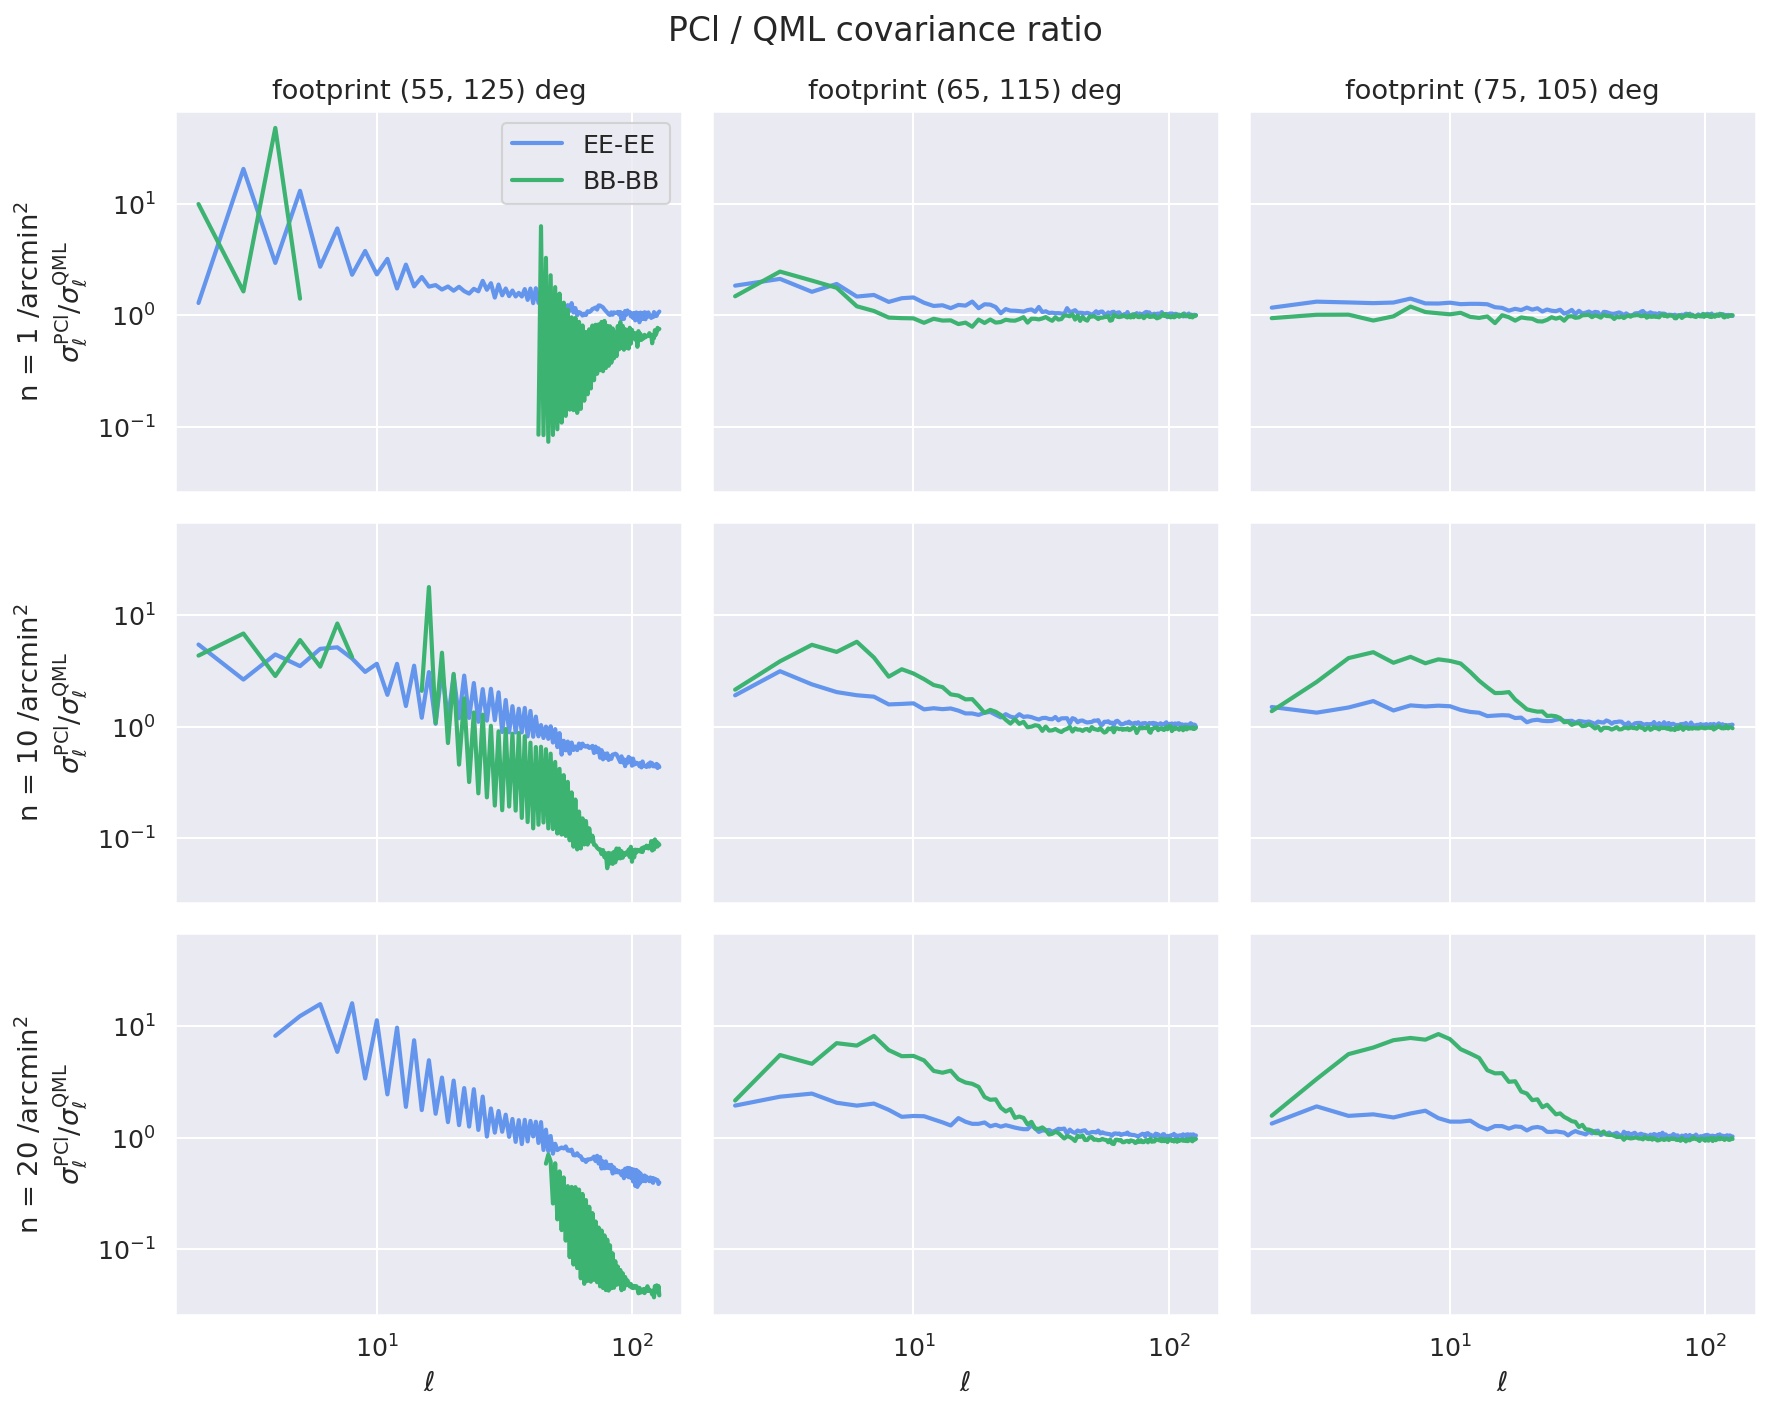

In [21]:
fig, axes = plt.subplots(len(n_arcmin2_values), len(footprints),
                          figsize=(4 * len(footprints), 3.2 * len(n_arcmin2_values)),
                          sharex=True, sharey=True, squeeze=False)

for row, n_arcmin2 in enumerate(n_arcmin2_values):
    for col, (lo, hi) in enumerate(footprints):
        ax = axes[row, col]
        data = results[(n_arcmin2, (lo, hi))]
        ells = data['ells']

        ax.loglog(ells, data['sigma_ratio_EE'], c='cornflowerblue', lw=2, label='EE-EE')
        ax.loglog(ells, data['sigma_ratio_BB'], c='mediumseagreen', lw=2, label='BB-BB')

        if row == 0:
            ax.set_title(f'footprint ({lo}, {hi}) deg')
        if col == 0:
            ax.set_ylabel(f'n = {n_arcmin2:g} /arcmin$^2$\n' + r'$\sigma_{\ell}^{\mathrm{PCl}} / \sigma_{\ell}^{\mathrm{QML}}$')
        if row == len(n_arcmin2_values) - 1:
            ax.set_xlabel(r'$\ell$')

axes[0, 0].legend()
fig.suptitle('PCl / QML covariance ratio')
plt.tight_layout()
plt.show()

## EE power spectrum estimates

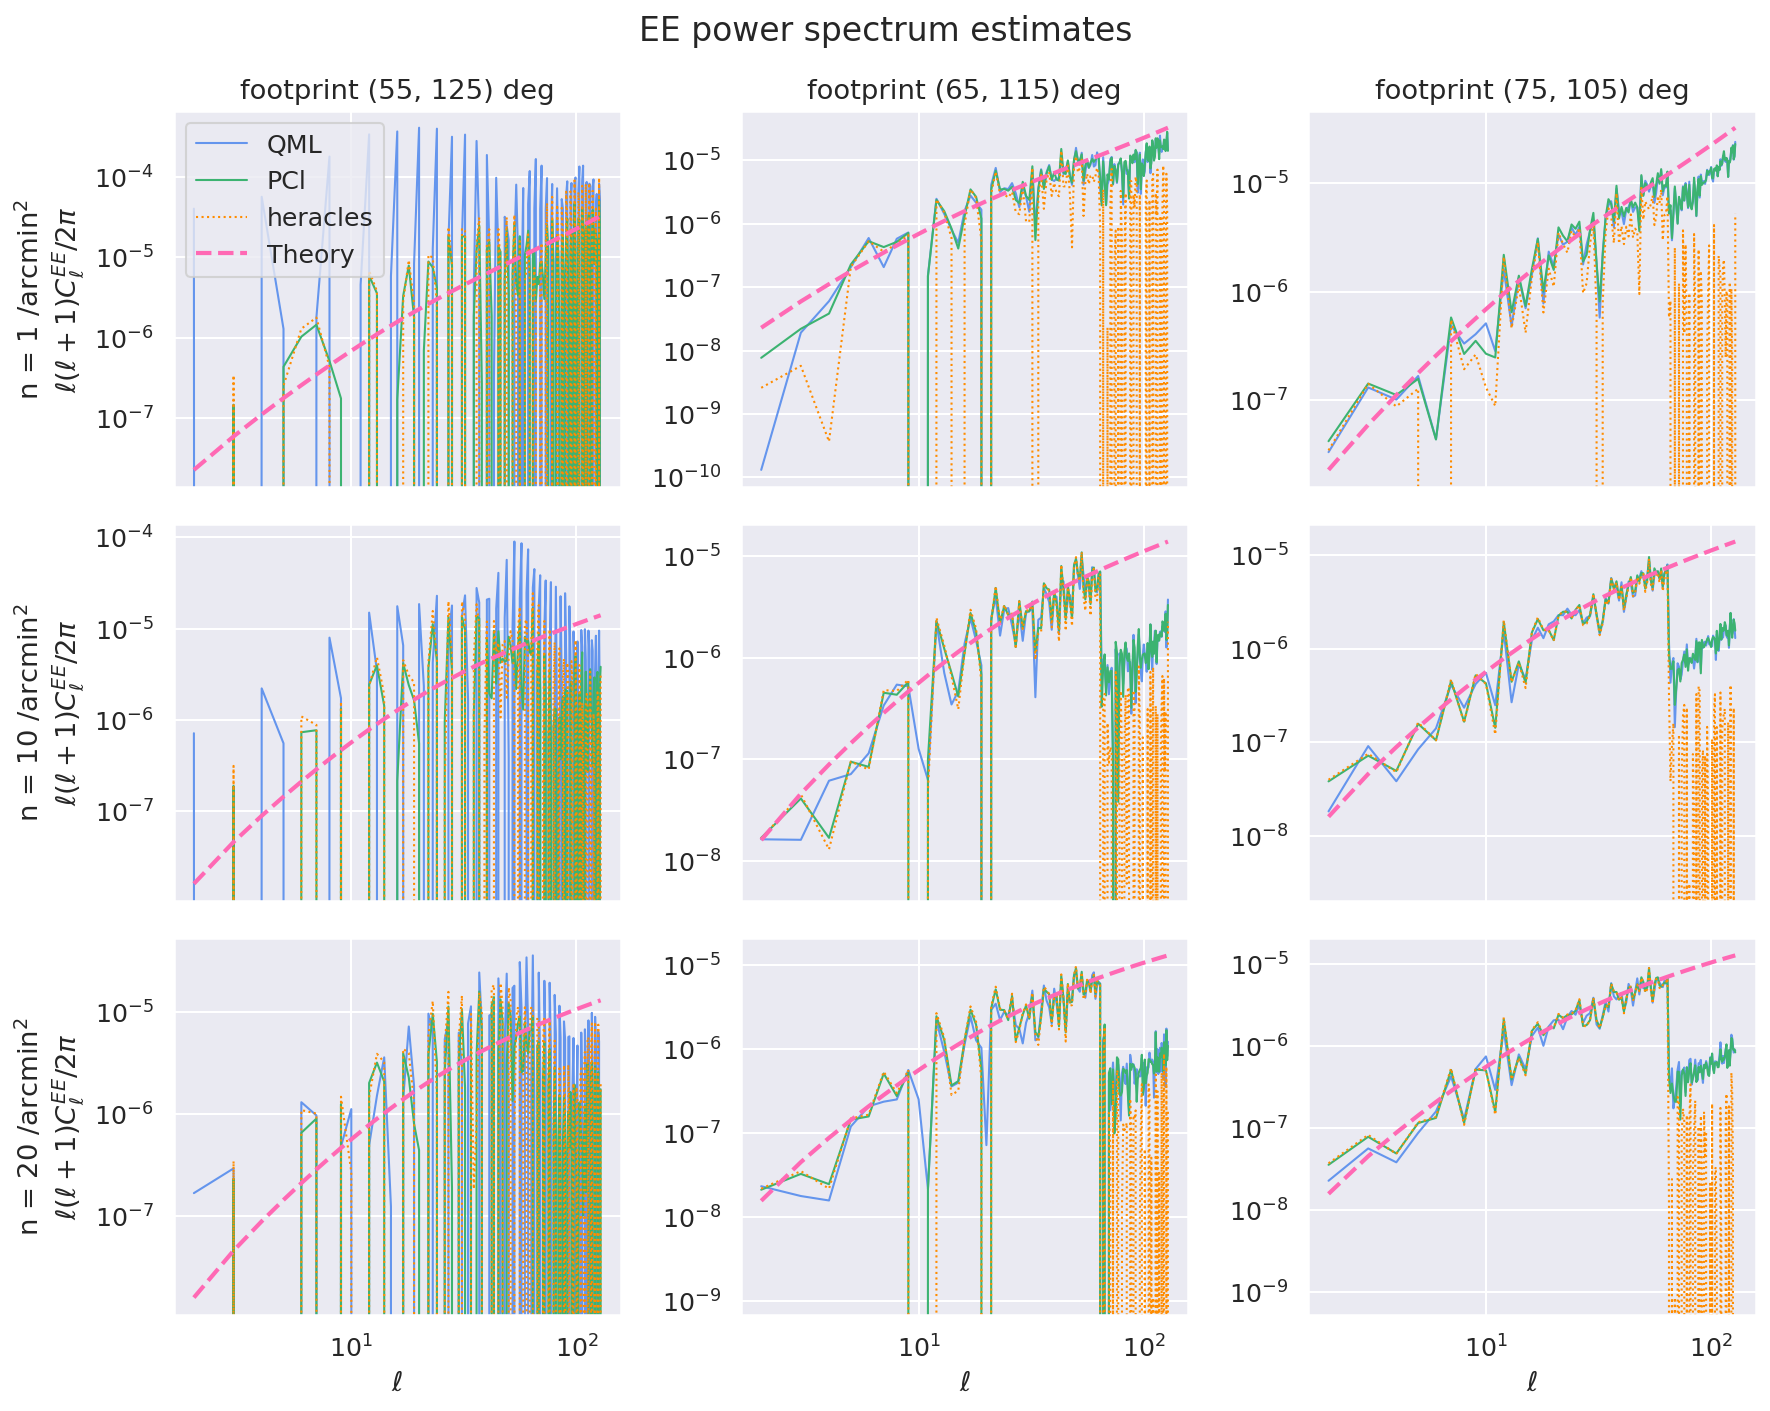

In [22]:
fig, axes = plt.subplots(len(n_arcmin2_values), len(footprints),
                          figsize=(4 * len(footprints), 3.2 * len(n_arcmin2_values)),
                          sharex=True, squeeze=False)

for row, n_arcmin2 in enumerate(n_arcmin2_values):
    for col, (lo, hi) in enumerate(footprints):
        ax = axes[row, col]
        data = results[(n_arcmin2, (lo, hi))]
        ells = data['ells']

        ax.loglog(ells, ells * (ells + 1) * data['cl_EE_QML'] / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
        ax.loglog(ells, ells * (ells + 1) * data['cl_EE_PCl'] / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')
        ax.loglog(ells, ells * (ells + 1) * data['cl_EE_heracles'] / (2 * np.pi), lw=1, ls=':', c='darkorange', label='heracles')
        ax.loglog(ells, ells * (ells + 1) * data['cl_EE_theory'] / (2 * np.pi), lw=2, ls='--', c='hotpink', label='Theory')

        if row == 0:
            ax.set_title(f'footprint ({lo}, {hi}) deg')
        if col == 0:
            ax.set_ylabel(f'n = {n_arcmin2:g} /arcmin$^2$\n' + r'$\ell(\ell+1) C_{\ell}^{EE} / 2\pi$')
        if row == len(n_arcmin2_values) - 1:
            ax.set_xlabel(r'$\ell$')

axes[0, 0].legend()
fig.suptitle('EE power spectrum estimates')
plt.tight_layout()
plt.show()

## BB power spectrum estimates

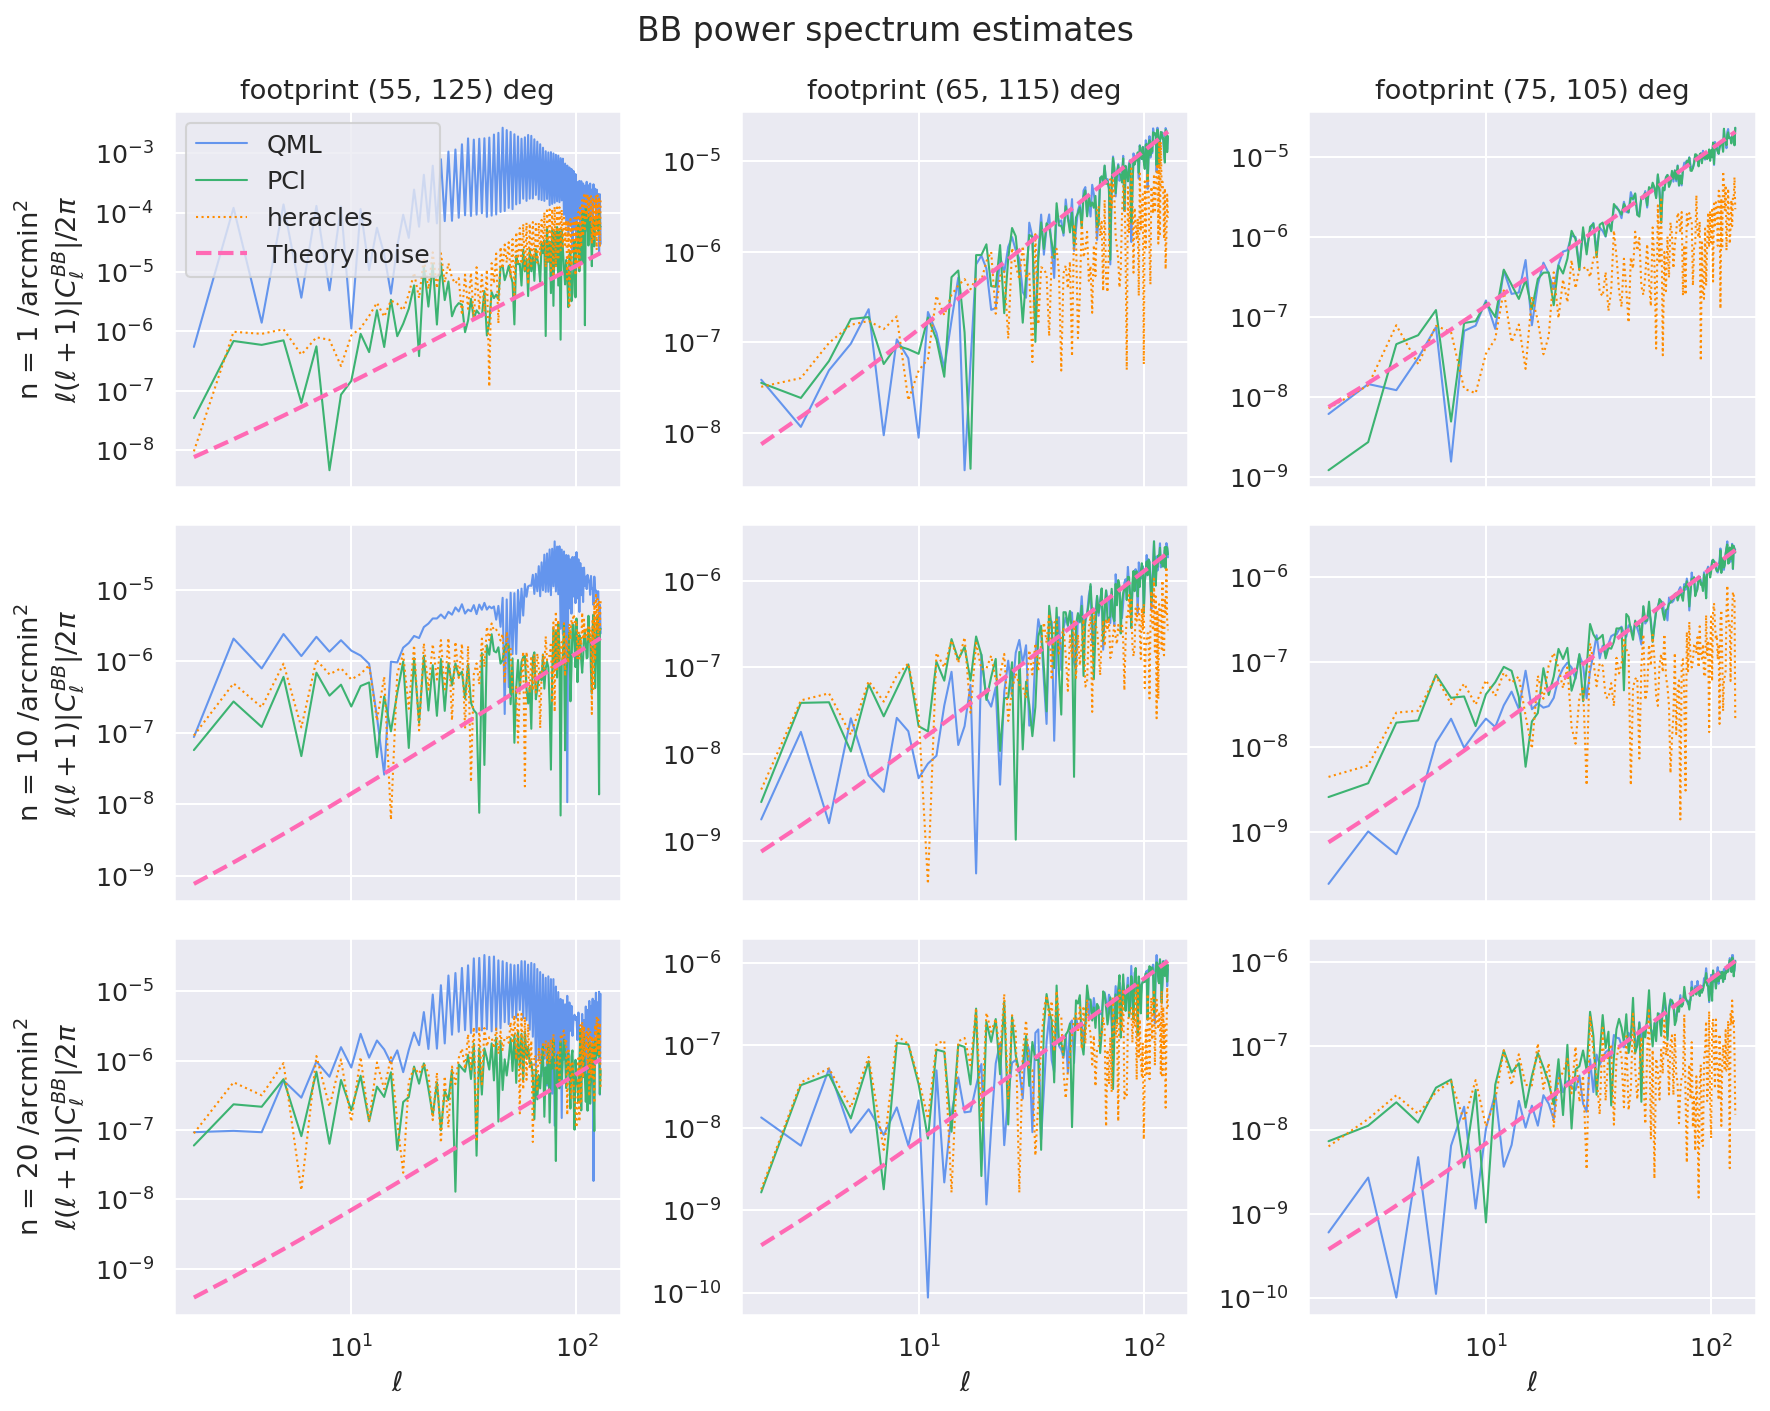

In [23]:
fig, axes = plt.subplots(len(n_arcmin2_values), len(footprints),
                          figsize=(4 * len(footprints), 3.2 * len(n_arcmin2_values)),
                          sharex=True, squeeze=False)

for row, n_arcmin2 in enumerate(n_arcmin2_values):
    for col, (lo, hi) in enumerate(footprints):
        ax = axes[row, col]
        data = results[(n_arcmin2, (lo, hi))]
        ells = data['ells']
        cl_noise = float(data['cl_noise'])

        ax.loglog(ells, ells * (ells + 1) * np.abs(data['cl_BB_QML']) / (2 * np.pi), lw=1, c='cornflowerblue', label='QML')
        ax.loglog(ells, ells * (ells + 1) * np.abs(data['cl_BB_PCl']) / (2 * np.pi), lw=1, c='mediumseagreen', label='PCl')
        ax.loglog(ells, ells * (ells + 1) * np.abs(data['cl_BB_heracles']) / (2 * np.pi), lw=1, ls=':', c='darkorange', label='heracles')
        ax.loglog(ells, ells * (ells + 1) * cl_noise / (2 * np.pi), lw=2, ls='--', c='hotpink', label='Theory noise')

        if row == 0:
            ax.set_title(f'footprint ({lo}, {hi}) deg')
        if col == 0:
            ax.set_ylabel(f'n = {n_arcmin2:g} /arcmin$^2$\n' + r'$\ell(\ell+1) |C_{\ell}^{BB}| / 2\pi$')
        if row == len(n_arcmin2_values) - 1:
            ax.set_xlabel(r'$\ell$')

axes[0, 0].legend()
fig.suptitle('BB power spectrum estimates')
plt.tight_layout()
plt.show()